In [1]:
import pandas as pd
import numpy as np
import os
# working dir
work_path = "C:/Users/wenlou/Documents/Python Scripts"
os.chdir(work_path)
from help_function import *

m_label = {'SCC': 74, 'BMS': 70}
fontsize = 16

# load data and config    
df_sim_BMS_unoised, df_mean_BMS_unoised = process_force0_data(m_label['BMS'], 'ConfLbl', 0, 70)
df_sim_BMS_noised, df_mean_BMS_noised = process_force0_data(m_label['BMS'], 'ConfLbl', 1, 70)


In [ ]:
norm = plt.Normalize(0, 1)
hue_order = [ "High", "Medium", "Low"]
color_map = {"Common": 'red', "Separate" : 'blue'}
#color_order = ['#00FFFF',  '#1E90FF', '#000080'] # blue- separate
color_order_map ={'Common': ['#FF7F7F', '#FF0000', '#800000'], 
                  "Separate": ['#00FFFF',  '#1E90FF', '#000080']} # color red - common
cmap = LinearSegmentedColormap.from_list('custom_cmap', [ 'blue', 'red']) # from blue (Separate) to red (High)

##the unoise plot
def plot_line_dots(df, df_mean, ax, sel='Separate'):
    dotVar = 'bi_xA'
    sns.lineplot(data = df_mean.loc[df_mean.ComSourLbl==sel], x = "delta_VA", y = "bi_sA_hat",  hue = "ConfLbl", hue_order = hue_order, palette = color_order, 
                    linestyle = '-',  linewidth=3,  errorbar=None, ax = ax, legend = None)
    sns.lineplot(data = df_mean.loc[df_mean.ComSourLbl==sel], x = "delta_VA", y = "bi_xA",  hue = "ConfLbl", hue_order = hue_order,   palette = color_order,
                linewidth=3, linestyle='--',  errorbar=None, ax = ax, legend = None)
    #cmap = LinearSegmentedColormap.from_list('custom_cmap', [ 'blue', 'red']) # from blue (Separate) to red (High)
    pcm1 = ax.scatter(df.loc[(df.ConfLbl == 'High') & (df.ComSourLbl==sel), 'delta_VA'] + 2, df.loc[(df.ConfLbl == 'High') & (df.ComSourLbl==sel), dotVar], 
                        c=df.loc[(df.ConfLbl == 'High') & (df.ComSourLbl==sel), 'prob_conf'], cmap=cmap, norm=norm, s=10)
    ax.scatter(df.loc[(df.ConfLbl == 'Medium') & (df.ComSourLbl==sel), 'delta_VA'], df.loc[(df.ConfLbl == 'Medium') & (df.ComSourLbl==sel), dotVar], 
                        c=df.loc[(df.ConfLbl == 'Medium') & (df.ComSourLbl==sel), 'prob_conf'], cmap=cmap, norm=norm, s=10)
    ax.scatter(df.loc[(df.ConfLbl == 'Low') & (df.ComSourLbl==sel), 'delta_VA'] - 2, df.loc[(df.ConfLbl == 'Low') & (df.ComSourLbl==sel), dotVar], 
                        c=df.loc[(df.ConfLbl == 'Low') & (df.ComSourLbl==sel), 'prob_conf'], cmap=cmap, norm=norm, s=10)
    return pcm1



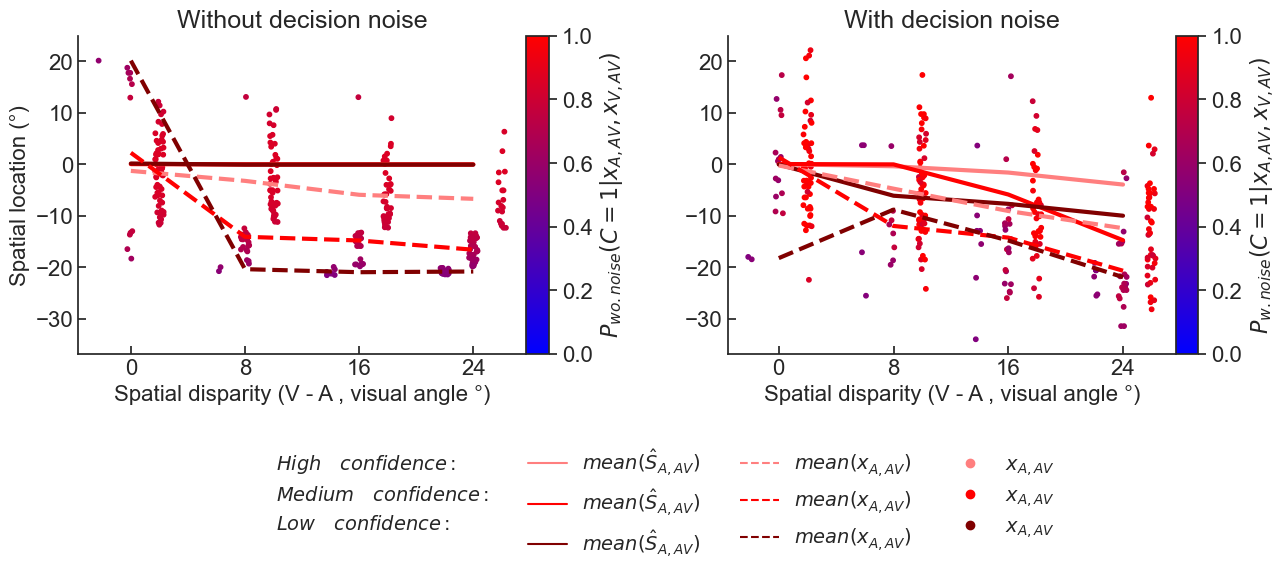

In [11]:
sel = 'Common'
color_order = color_order_map[sel]

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 5, width_ratios=[1,  0.05, 0.4,  1, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[3], sharey = ax1)
cax1 = fig.add_subplot(gs[1])
cax2 = fig.add_subplot(gs[4])

pcm1 = plot_line_dots(df_sim_BMS_unoised, df_mean_BMS_unoised, ax1, sel)
cbar1 = plt.colorbar(pcm1, cax=cax1)
cbar1.set_label(r'$P_{wo.noise}(C=1|x_{A, AV}, x_{V, AV})$', fontsize = fontsize)
cbar1.ax.tick_params(labelsize=fontsize) 
pcm2 = plot_line_dots(df_sim_BMS_noised, df_mean_BMS_noised, ax2, sel)
cbar2 = plt.colorbar(pcm2, cax=cax2)
cbar2.set_label(r'$P_{w.noise}(C=1|x_{A, AV}, x_{V, AV})$', fontsize = fontsize)
cbar2.ax.tick_params(labelsize=fontsize) 

ax1.set_title('Without decision noise', fontsize = fontsize+2)
ax2.set_title('With decision noise', fontsize = fontsize+2)
for ax in [ax1, ax2]:
    clean_axs(ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlabel('Spatial disparity (V - A , visual angle \u00B0)', fontsize = fontsize)
ax1.set_ylabel('Spatial location (\u00B0)', fontsize = fontsize)

#color_order = ['#000080',  '#1E90FF',  '#00FFFF']
# Create custom legend handles
custom_legend_handles = [mlines.Line2D([], [], color=color_order[0], linestyle='-'),
                        mlines.Line2D([], [], color=color_order[1], linestyle='-'),
                        mlines.Line2D([], [], color=color_order[2], linestyle='-'),
                        
                        mlines.Line2D([], [], color=color_order[0], linestyle='--'), 
                        mlines.Line2D([], [], color=color_order[1], linestyle='--'), 
                        mlines.Line2D([], [], color=color_order[2], linestyle='--'),
                        mlines.Line2D([], [], color=color_order[0], marker='o', linestyle=''),
                        mlines.Line2D([], [], color=color_order[1], marker='o', linestyle=''),
                        mlines.Line2D([], [], color=color_order[2], marker='o', linestyle='')
                        ]

row_labels = [
    mlines.Line2D([], [], linestyle='', marker=''),
    mlines.Line2D([], [], linestyle='', marker=''),
    mlines.Line2D([], [], linestyle='', marker='')]
all_handles = row_labels + custom_legend_handles
all_labels = [r'$High \quad confidence :$' , r'$Medium \quad confidence :$', r'$Low \quad confidence :$', 
            r'$mean(\hat{S}_{A,AV})$', r'$mean(\hat{S}_{A,AV})$', r'$mean(\hat{S}_{A,AV})$',  
            r'$mean(x_{A,AV}^{})$', r'$mean(x_{A,AV}^{})$',  r'$mean(x_{A,AV}^{})$', r'$x_{A,AV}$',r'$x_{A,AV}$',r'$x_{A,AV}$']
fig.legend(handles=all_handles, 
        labels=all_labels,
        ncol=4, fontsize=fontsize-2, bbox_to_anchor=(0.5, -0.02), loc='lower center', frameon=False)
#fig.suptitle(, fontsize = fontsize)
fig.subplots_adjust(bottom = 0.35, left = 0.1)

plt.savefig(os.path.join(work_path, "plot4paper", "conf_dist_" + sel + "_0827.png"), dpi=300)  # Adjust dpi for print quality
plt.show()
